In [42]:
import numpy as np
from astropy import units as u
from astropy.time import Time
from poliastro.bodies import Moon
from poliastro.twobody import Orbit

print("Imports worked")


Imports worked


# Pablo's Code

Saved mask: C:\Users\sabri\OneDrive\Documentos\GPS\FINAL\DATA/mask_GruithuisenDomes.csv
Saved mask: C:\Users\sabri\OneDrive\Documentos\GPS\FINAL\DATA/mask_MariusHills.csv
Saved mask: C:\Users\sabri\OneDrive\Documentos\GPS\FINAL\DATA/mask_RimaBode.csv
Saved mask: C:\Users\sabri\OneDrive\Documentos\GPS\FINAL\DATA/mask_Shackleton.csv

--- GruithuisenDomes skyplot ---


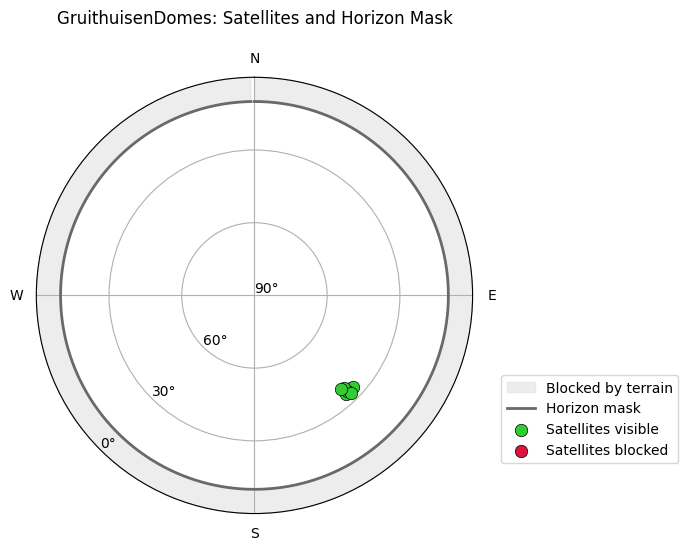


--- MariusHills skyplot ---


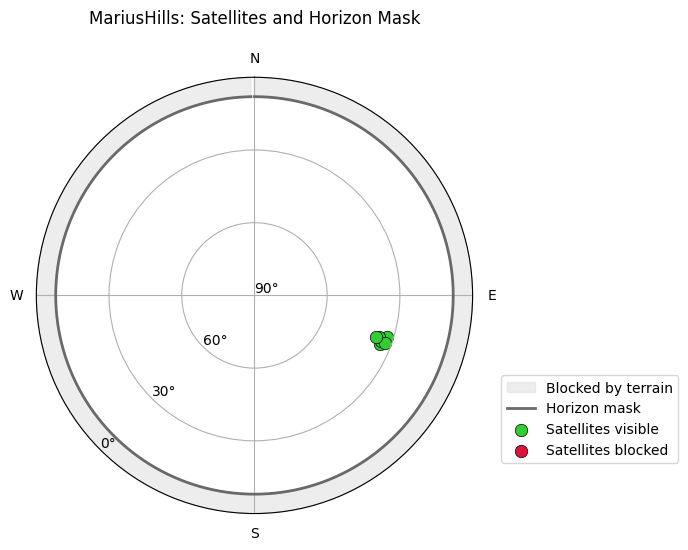


--- RimaBode skyplot ---


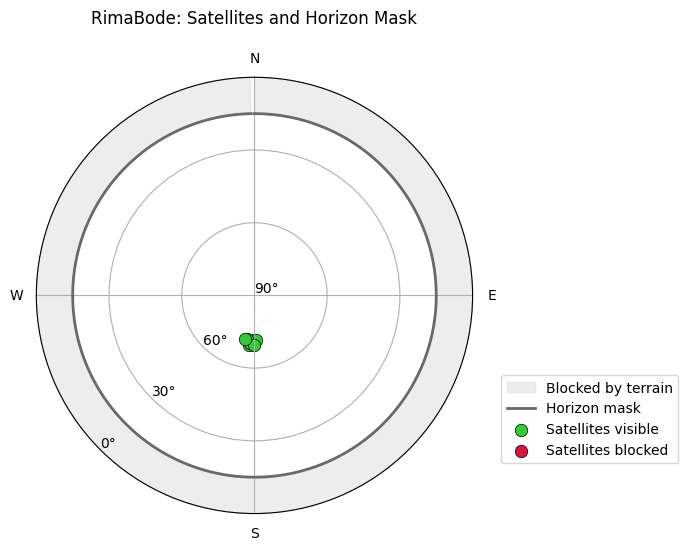


--- Shackleton skyplot ---


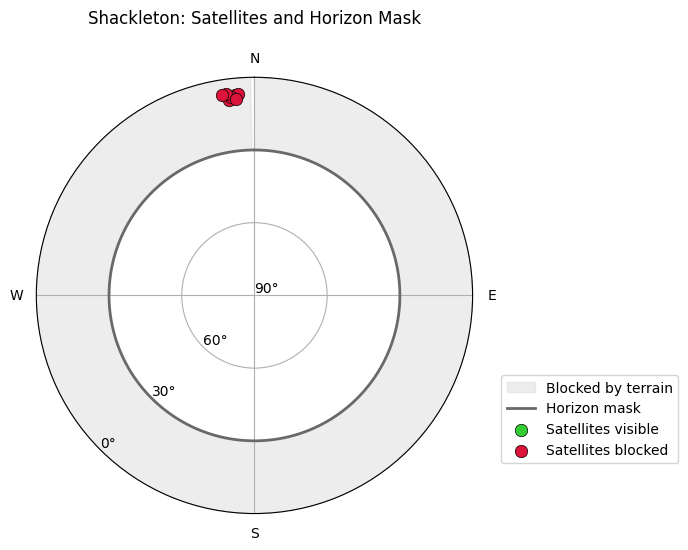


=== GruithuisenDomes DOP ===
  Satellites (open sky)   : 7
  Satellites (after mask) : 7
  PDOP open sky           : 1364.55


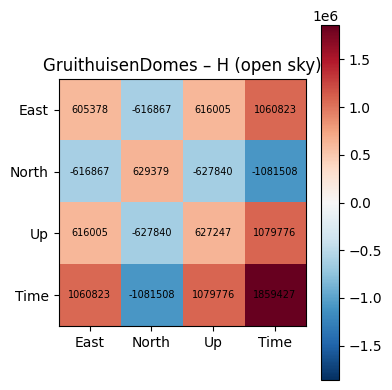

  PDOP with mask          : 1364.55


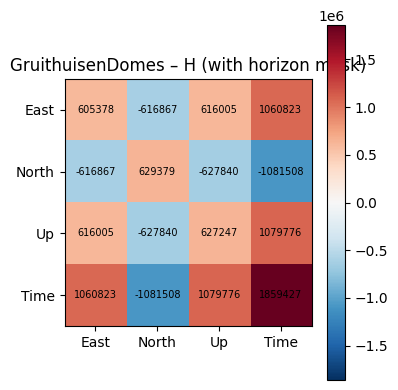


=== MariusHills DOP ===
  Satellites (open sky)   : 7
  Satellites (after mask) : 7
  PDOP open sky           : 1364.81


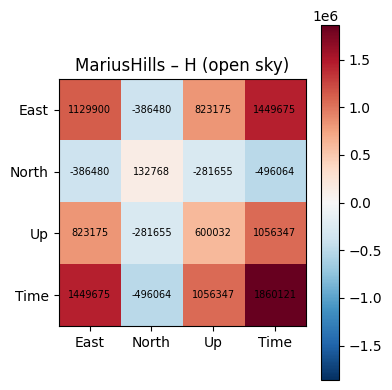

  PDOP with mask          : 1364.81


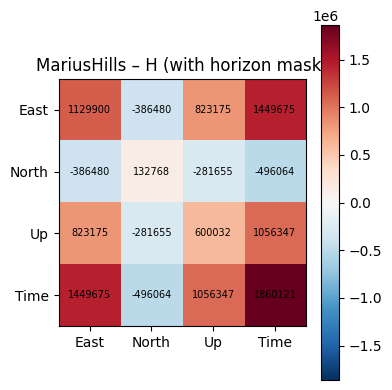


=== RimaBode DOP ===
  Satellites (open sky)   : 7
  Satellites (after mask) : 7
  PDOP open sky           : 1359.58


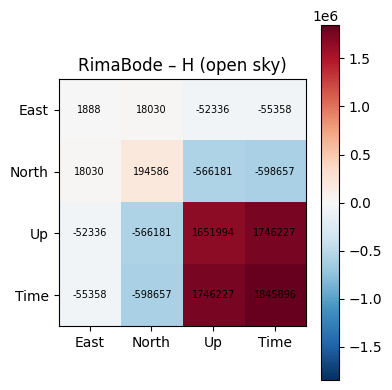

  PDOP with mask          : 1359.58


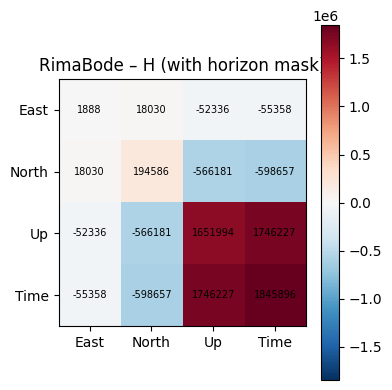


=== Shackleton DOP ===
  Satellites (open sky)   : 7
  Satellites (after mask) : 0
  PDOP open sky           : 1372.15


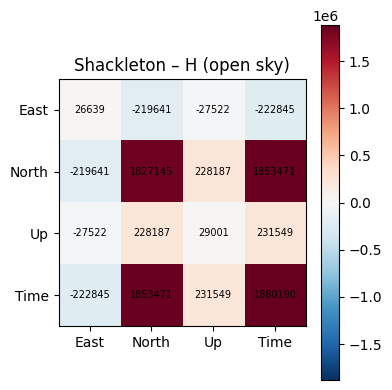

  Not enough visible satellites after mask to compute DOP.


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# from google.colab import drive
# drive.mount('/content/drive')

# 0. Paths and simple mask generation

BASE = r"C:\Users\sabri\OneDrive\Documentos\GPS\FINAL\DATA" # CHANGED TO MY OWN PATH

# Satellite az/el CSVs from your HW (matching your Drive)
sat_files = {
    "GruithuisenDomes" : f"{BASE}/hw2_p3_bonus_GruithuisenDomes.csv",
    "MariusHills"      : f"{BASE}/hw2_p3_bonus_MariusHills.csv",
    "RimaBode"         : f"{BASE}/hw2_p3_bonus_RimaBode.csv",
    "Shackleton"       : f"{BASE}/hw2_p3_bonus_Shackleton.csv",
}

# Simple constant masks (deg) – good for testing
mask_levels = {
    "GruithuisenDomes" : 10,
    "MariusHills"      : 8,
    "RimaBode"         : 15,
    "Shackleton"       : 30,
}

# Create mask CSVs (safe to rerun)
def make_mask(filename, elev_value):
    az = np.arange(360)
    elev = np.full(360, elev_value)
    df = pd.DataFrame({"az_deg": az, "elev_mask_deg": elev})
    df.to_csv(filename, index=False)
    print("Saved mask:", filename)

mask_files = {}
for loc, level in mask_levels.items():
    fname = f"{BASE}/mask_{loc}.csv"
    make_mask(fname, level)
    mask_files[loc] = fname

# 1. DOP utilities

def get_unit_vector(az_deg, el_deg):
    az = np.deg2rad(az_deg)
    el = np.deg2rad(el_deg)
    uE = np.cos(el) * np.sin(az)
    uN = np.cos(el) * np.cos(az)
    uU = np.sin(el)
    u  = np.array([uE, uN, uU], dtype=float)
    n  = np.linalg.norm(u)
    return u / n if n > 0 else u

def compute_dop_matrix(az_arr, el_arr):
    az_arr = np.asarray(az_arr, float).ravel()
    el_arr = np.asarray(el_arr, float).ravel()
    if az_arr.size < 4:
        raise ValueError("Need at least 4 satellites to compute DOP.")
    rows = []
    for az, el in zip(az_arr, el_arr):
        uE, uN, uU = get_unit_vector(az, el)
        rows.append([-uE, -uN, -uU, 1.0])
    G = np.asarray(rows)
    H = np.linalg.inv(G.T @ G)
    return H, G

def compute_pdop(H):
    return float(np.sqrt(H[0,0] + H[1,1] + H[2,2]))

def compute_hdop(H):
    return float(np.sqrt(H[0,0] + H[1,1]))

def compute_vdop(H):
    return float(np.sqrt(H[2,2]))

def compute_tdop(H):
    return float(np.sqrt(H[3,3]))

def plot_dop_matrix(H, title=""):
    plt.figure(figsize=(4,4))
    vmax = max(20, np.max(np.abs(H)))   # symmetric, but clip for visibility
    plt.imshow(H, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    plt.colorbar()
    labels = ["East", "North", "Up", "Time"]
    plt.xticks(range(4), labels)
    plt.yticks(range(4), labels)
    for (i, j), val in np.ndenumerate(H):
        plt.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=7)
    plt.title(title)
    plt.tight_layout()

# 2. Load satellite and mask data

def load_sat_data(path):
    df = pd.read_csv(path)
    az = df["az_sv_deg"].values
    el = df["el_sv_deg"].values
    return az, el

def load_mask(path):
    dfm = pd.read_csv(path)
    az_mask = dfm["az_deg"].values.astype(float)
    elev_mask = dfm["elev_mask_deg"].values.astype(float)
    idx = np.argsort(az_mask)
    return az_mask[idx], elev_mask[idx]


# 3. Horizon mask visibility

def visible_with_mask(az_sat_deg, el_sat_deg, az_mask_deg, elev_mask_deg):
    az = az_sat_deg % 360.0
    elev_req = np.interp(az, az_mask_deg, elev_mask_deg)
    return el_sat_deg > elev_req, elev_req

def compute_masked_geometry(az_sat, el_sat, az_mask, elev_mask):
    az_vis, el_vis = [], []
    for a, e in zip(az_sat, el_sat):
        vis, _ = visible_with_mask(a, e, az_mask, elev_mask)
        if vis:
            az_vis.append(a)
            el_vis.append(e)
    return np.array(az_vis), np.array(el_vis)

# 4. Skyplot with horizon mask + visible/blocked sats

def plot_sky_with_mask(location_name, sat_path, mask_path):
    az_sat, el_sat = load_sat_data(sat_path)
    az_mask, elev_mask = load_mask(mask_path)

    # classify sats
    visible_flags = []
    for a, e in zip(az_sat, el_sat):
        vis, _ = visible_with_mask(a, e, az_mask, elev_mask)
        visible_flags.append(vis)
    visible_flags = np.array(visible_flags, dtype=bool)

    # polar coords
    theta_sat = np.deg2rad(az_sat)
    r_sat     = 90.0 - el_sat

    theta_mask = np.deg2rad(az_mask)
    r_mask     = 90.0 - elev_mask

    plt.figure(figsize=(7,7))
    ax = plt.subplot(111, polar=True)

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    # full sky: 0–90 deg elevation
    ax.set_rlim(0, 90)
    ax.set_rticks([90, 60, 30, 0])
    ax.set_yticklabels(["0°", "30°", "60°", "90°"])
    ax.set_rlabel_position(225)
    ax.set_thetagrids([0, 90, 180, 270], labels=["N","E","S","W"])

    # blocked region from rim to horizon
    theta_poly = np.concatenate([theta_mask, theta_mask[::-1]])
    r_poly = np.concatenate([r_mask, np.full_like(r_mask, 90.0)])
    ax.fill(theta_poly, r_poly, color="lightgray", alpha=0.4, label="Blocked by terrain")

    # mask curve
    ax.plot(theta_mask, r_mask, color="dimgray", linewidth=2, label="Horizon mask")

    # satellites
    ax.scatter(theta_sat[visible_flags],
               r_sat[visible_flags],
               s=80, c="limegreen", edgecolors="k", linewidths=0.5,
               label="Satellites visible")
    ax.scatter(theta_sat[~visible_flags],
               r_sat[~visible_flags],
               s=80, c="crimson", edgecolors="k", linewidths=0.5,
               label="Satellites blocked")

    ax.set_title(f"{location_name}: Satellites and Horizon Mask", pad=20)
    ax.legend(loc="lower left", bbox_to_anchor=(1.05, 0.1))
    plt.tight_layout()
    plt.show()

# 5. Run: skyplots + H matrices for all craters

# 5a. Skyplots
for loc in sat_files.keys():
    print(f"\n--- {loc} skyplot ---")
    plot_sky_with_mask(loc, sat_files[loc], mask_files[loc])

# 5b. H matrices and PDOP with/without mask
for loc in sat_files.keys():
    print(f"\n=== {loc} DOP ===")

    az_sat, el_sat = load_sat_data(sat_files[loc])
    az_mask, elev_mask = load_mask(mask_files[loc])

    # open-sky geometry
    H_open, _ = compute_dop_matrix(az_sat, el_sat)
    pdop_open = compute_pdop(H_open)

    # masked geometry
    az_vis, el_vis = compute_masked_geometry(az_sat, el_sat, az_mask, elev_mask)
    n_open = len(az_sat)
    n_vis  = len(az_vis)

    print(f"  Satellites (open sky)   : {n_open}")
    print(f"  Satellites (after mask) : {n_vis}")
    print(f"  PDOP open sky           : {pdop_open:.2f}")

    plot_dop_matrix(H_open, title=f"{loc} – H (open sky)")
    plt.show()

    if n_vis >= 4:
        H_mask, _ = compute_dop_matrix(az_vis, el_vis)
        pdop_mask = compute_pdop(H_mask)
        print(f"  PDOP with mask          : {pdop_mask:.2f}")
        plot_dop_matrix(H_mask, title=f"{loc} – H (with horizon mask)")
        plt.show()
    else:
        print("  Not enough visible satellites after mask to compute DOP.")


# 1. Shackleton Only Analysis


--- Shackleton skyplot ---


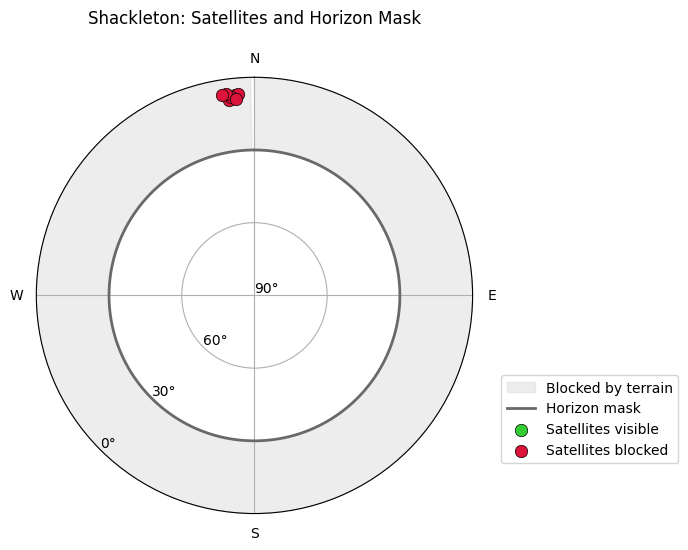


=== Shackleton DOP ===
  Satellites (open sky)   : 7
  Satellites (after mask) : 0
  PDOP open sky           : 1372.15


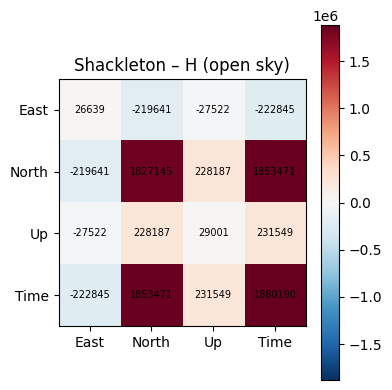

  Not enough visible satellites after mask to compute DOP.


In [44]:
# Shackleton-only analysis

loc = "Shackleton" #changed from Pablo's code
print(f"\n--- {loc} skyplot ---")
plot_sky_with_mask(loc, sat_files[loc], mask_files[loc])

print(f"\n=== {loc} DOP ===")

# Load satellite az/el
az_sat, el_sat = load_sat_data(sat_files[loc])

# Load horizon mask (currently the simple placeholder mask, will use henry's file)
az_mask, elev_mask = load_mask(mask_files[loc])

# Open-sky geometry (no terrain mask)
H_open, _ = compute_dop_matrix(az_sat, el_sat)
pdop_open = compute_pdop(H_open)

# Apply horizon mask to get only visible satellites
az_vis, el_vis = compute_masked_geometry(az_sat, el_sat, az_mask, elev_mask)
n_open = len(az_sat)
n_vis  = len(az_vis)

print(f"  Satellites (open sky)   : {n_open}")
print(f"  Satellites (after mask) : {n_vis}")
print(f"  PDOP open sky           : {pdop_open:.2f}")

# Plot H matrix for open-sky case
plot_dop_matrix(H_open, title=f"{loc} – H (open sky)")
plt.show()

# Masked PDOP (only if enough sats survive)
if n_vis >= 4:
    H_mask, _ = compute_dop_matrix(az_vis, el_vis)
    pdop_mask = compute_pdop(H_mask)
    print(f"  PDOP with mask          : {pdop_mask:.2f}")
    plot_dop_matrix(H_mask, title=f"{loc} – H (with horizon mask)")
    plt.show()
else:
    print("  Not enough visible satellites after mask to compute DOP.")

# 2. Lunar Satellite Orbit

In [45]:
# Define a 100 km circular polar lunar orbit with poliastro
# (based on the poliastro quickstart docs)

# Define epoch (from poliastro docs)
epoch = Time("2025-01-01 00:00:00", scale="tdb")

# orbit parameters
altitude = 100 * u.km         # 100 km above surface (classic lLO)
inclination = 90 * u.deg      # polar orbit (max coverage of South Pole crater)

# Create a circular polar orbit around the Moon
#    Using Orbit.circular() from poliastro doc
lunar_orbit = Orbit.circular(
    Moon,
    alt=altitude,
    inc=inclination,
    epoch=epoch,
)

print("LLO orbit object:")
print(lunar_orbit)

# Sample times — one full orbital period, 200 samples
#    lunar_orbit.period is from poliastro docs
N_samples = 200
period = lunar_orbit.period
times = epoch + np.linspace(0, period.to(u.s).value, N_samples) * u.s

# Propagate the orbit over each time sample
#    rv.r gives Moon-centered position in astropy units -> convert to meters
r_list = []
for t in times:
    rv = lunar_orbit.propagate(t - epoch)   # propagate from epoch to time t
    r_vec = rv.r.to(u.m).value              # convert to numpy (3,)
    r_list.append(r_vec)

# Final array of Moon-centered satellite positions
r_moon = np.array(r_list)  # shape: (N_samples, 3)

print("\nFirst 3 position vectors (Moon-centered) [m]:")
print(r_moon[:3])
print(f"\nOrbital period ~ {period.to(u.hour):.2f}")
print(f"Number of samples: {N_samples}")

LLO orbit object:
1837 x 1837 km x 90.0 deg orbit around Moon (☾)

First 3 position vectors (Moon-centered) [m]:
[[1.83740000e+06 0.00000000e+00 0.00000000e+00]
 [1.83648422e+06 3.55172391e-12 5.80040533e+04]
 [1.83373779e+06 7.09990739e-12 1.15950287e+05]]

Orbital period ~ 1.96 h
Number of samples: 200


In [46]:
# Define a 500 km circular polar "MLO" lunar orbit with poliastro
# Same method as Part 2 for LLO, just higher altitude.

# Epoch (same as before so we can compare orbits)
epoch_MLO = Time("2025-01-01 00:00:00", scale="tdb")

# Orbit parameters for MLO
altitude_MLO = 500 * u.km      # 500 km above lunar surface
inclination_MLO = 90 * u.deg   # polar again

# Create circular polar orbit (MLO)
lunar_orbit_MLO = Orbit.circular(
    Moon,
    alt=altitude_MLO,
    inc=inclination_MLO,
    epoch=epoch_MLO,
)

print("MLO orbit object:")
print(lunar_orbit_MLO)

# Sample times over one full MLO period
N_samples_MLO = 200
period_MLO = lunar_orbit_MLO.period
times_MLO = epoch_MLO + np.linspace(0, period_MLO.to(u.s).value, N_samples_MLO) * u.s

# Propagate and collect Moon-centered positions
r_list_MLO = []
for t in times_MLO:
    rv_MLO = lunar_orbit_MLO.propagate(t - epoch_MLO)
    r_vec_MLO = rv_MLO.r.to(u.m).value   # (3,) numpy vector
    r_list_MLO.append(r_vec_MLO)

# Final array of positions for the MLO case
r_moon_MLO = np.array(r_list_MLO)   # shape: (N_samples_MLO, 3)

print("\nFirst 3 MLO position vectors (Moon-centered) [m]:")
print(r_moon_MLO[:3])
print(f"\nMLO orbital period ~ {period_MLO.to(u.hour):.2f}")
print(f"Number of samples: {N_samples_MLO}")

MLO orbit object:
2237 x 2237 km x 90.0 deg orbit around Moon (☾)

First 3 MLO position vectors (Moon-centered) [m]:
[[2.23740000e+06 0.00000000e+00 0.00000000e+00]
 [2.23628486e+06 4.32493038e-12 7.06314732e+04]
 [2.23294053e+06 8.64554958e-12 1.41192539e+05]]

MLO orbital period ~ 2.64 h
Number of samples: 200


In [47]:
# LLO
dt_LLO = period.to(u.s).value / (N_samples - 1)     # seconds per sample
T_orbit_LLO = period.to(u.s).value                  # total seconds

# MLO
dt_MLO = period_MLO.to(u.s).value / (N_samples_MLO - 1)
T_orbit_MLO = period_MLO.to(u.s).value

print (T_orbit_LLO, 's')
print (T_orbit_MLO, 's')

7067.459950293022 s
9496.711366137653 s


# 3. Convert satellite positions to az/el at Shackleton

In [48]:
# Math follows the standard ECEF→ENU rotation from ESA Navipedia
# ("Transformations between ECEF and ENU coordinates")
# and is equivalent to the geodetic2ecef / ecef2enu logic used in pymap3d.

# Define Shackleton crater location (lat/lon on the Moon)

shack_lat_deg = -89.9   # latitude [deg] (near lunar south pole, negative = south)
shack_lon_deg =   0.0   # longitude [deg] (choose reference meridian used in your data)

# Moon radius
R_moon = 1737.4e3  # [m]


def geodetic_to_moon_ecef(lat_deg, lon_deg, radius=R_moon):
    """
    Simple spherical geodetic -> Moon-centered 'ECEF' (x,y,z).
    Using the standard formulas (same structure as Navipedia / pymap3d).
    """
    lat = np.deg2rad(lat_deg)
    lon = np.deg2rad(lon_deg)

    x = radius * np.cos(lat) * np.cos(lon)
    y = radius * np.cos(lat) * np.sin(lon)
    z = radius * np.sin(lat)

    return np.array([x, y, z])


def enu_rotation_matrix(lat_deg, lon_deg):
    """
    Build the ECEF->ENU rotation matrix at a given lat/lon.
    This is directly from the ESA ENU math:
      - East  = [-sin λ,        cos λ,        0]
      - North = [-sin φ cos λ, -sin φ sin λ,  cos φ]
      - Up    = [ cos φ cos λ,  cos φ sin λ,  sin φ]
    Rows are [E; N; U], so R @ r_ecef gives ENU.
    """
    lat = np.deg2rad(lat_deg)
    lon = np.deg2rad(lon_deg)

    sin_lat = np.sin(lat)
    cos_lat = np.cos(lat)
    sin_lon = np.sin(lon)
    cos_lon = np.cos(lon)

    # Each row is one ENU basis vector expressed in ECEF
    east  = np.array([-sin_lon,             cos_lon,            0.0])
    north = np.array([-sin_lat * cos_lon,  -sin_lat * sin_lon,  cos_lat])
    up    = np.array([ cos_lat * cos_lon,   cos_lat * sin_lon,  sin_lat])

    R = np.vstack([east, north, up])  # 3x3
    return R


def sat_xyz_to_az_el(r_sat_array, lat_deg, lon_deg, radius=R_moon):
    """
    Main helper:
    - r_sat_array: shape (N,3), Moon-centered positions for the satellite [m]
                   (this will be r_moon or r_moon_MLO from Part 2)
    - lat_deg, lon_deg: Shackleton location
    - radius: Moon radius

    Returns:
      az_deg: azimuth angles [deg]
      el_deg: elevation angles [deg]
    """
    r_sat_array = np.asarray(r_sat_array)
    N = r_sat_array.shape[0]

    # Position of Shackleton "receiver" in Moon-fixed frame (ECEF-like)
    r_user = geodetic_to_moon_ecef(lat_deg, lon_deg, radius)

    # ECEF to ENU rotation matrix at Shackleton
    R_ecef2enu = enu_rotation_matrix(lat_deg, lon_deg)

    az_list = []
    el_list = []

    for i in range(N):
        r_sat = r_sat_array[i, :]

        # Line-of-sight vector from user to satellite in Moon-fixed coordinates
        rho_ecef = r_sat - r_user

        # Convert LOS into local ENU frame
        rho_enu = R_ecef2enu @ rho_ecef
        E, Nn, U = rho_enu  # east, north, up components

        # Azimuth and elevation (standard ENU definitions)
        # az = atan2(E, N), measured from North, positive toward East
        # el = atan2(U, sqrt(E^2 + N^2))
        az = np.arctan2(E, Nn)
        horiz_norm = np.sqrt(E**2 + Nn**2)
        el = np.arctan2(U, horiz_norm)

        az_list.append(np.rad2deg(az))
        el_list.append(np.rad2deg(el))

    return np.array(az_list), np.array(el_list)


# Use this for my two orbits from Part 2 (LLO and MLO)

# r_moon     : from the 100 km LLO poliastro code (shape: N,3)
# r_moon_MLO : from the 500 km MLO poliastro code (shape: N,3)

az_lunar_LLO, el_lunar_LLO = sat_xyz_to_az_el(
    r_moon, shack_lat_deg, shack_lon_deg, radius=R_moon
)

az_lunar_MLO, el_lunar_MLO = sat_xyz_to_az_el(
    r_moon_MLO, shack_lat_deg, shack_lon_deg, radius=R_moon
)

print("LLO az/el (first 3):")
print(np.vstack([az_lunar_LLO[:3], el_lunar_LLO[:3]]).T)

print("\nMLO az/el (first 3):")
print(np.vstack([az_lunar_MLO[:3], el_lunar_MLO[:3]]).T)


LLO az/el (first 3):
[[ 0.00000000e+00 -4.33448514e+01]
 [ 1.10802957e-16 -4.42992449e+01]
 [ 2.21814951e-16 -4.52521353e+01]]

MLO az/el (first 3):
[[ 0.00000000e+00 -3.77678863e+01]
 [ 1.10802957e-16 -3.88934387e+01]
 [ 2.21814951e-16 -4.00125183e+01]]


# 4. Apply Horizon Mask

In [49]:
import numpy as np

def load_henry_mask(csv_path):
    """
    Load crater horizon mask file.

    File format:
        az_deg,elev_mask_deg
     Returns:
        az_mask   (numpy array, sorted ascending)
        elev_mask (same length)
    """
    # Skip header row, use comma delimiter
    data = np.loadtxt(csv_path, delimiter=",", skiprows=1)

    az = data[:, 0]
    elev = data[:, 1]

    # Sort by azimuth for safe interpolation
    idx = np.argsort(az)
    az_sorted = az[idx]
    elev_sorted = elev[idx]

    return az_sorted, elev_sorted

In [50]:
# Apply Shackleton horizon mask to LLO and MLO orbits
# Reusing Pablo's helpers: load_mask, compute_masked_geometry, mask_files
# Reusing my az/el arrays from Part 3: az_lunar_LLO, el_lunar_LLO, az_lunar_MLO, el_lunar_MLO

# Load Shackleton horizon mask=
loc = "Shackleton"
mask_file = r"C:\Users\sabri\OneDrive\Documentos\GPS\FINAL\DATA\crater_horizon_map2.csv"
az_mask, elev_mask = load_henry_mask(mask_file)


# Apply mask to my LLO orbit (100 km)
az_lunar_LLO_vis, el_lunar_LLO_vis = compute_masked_geometry(
    az_lunar_LLO, el_lunar_LLO, az_mask, elev_mask
)

# Apply mask to my MLO orbit (500 km)
az_lunar_MLO_vis, el_lunar_MLO_vis = compute_masked_geometry(
    az_lunar_MLO, el_lunar_MLO, az_mask, elev_mask
)

# stats: how often is each orbit actually visible above the rim?
N_LLO_total = len(az_lunar_LLO)
N_MLO_total = len(az_lunar_MLO)

N_LLO_vis = len(az_lunar_LLO_vis)
N_MLO_vis = len(az_lunar_MLO_vis)

print(f"Shackleton mask: {loc}")
print(f"  LLO (100 km): {N_LLO_vis} / {N_LLO_total} samples visible "
      f"({100.0 * N_LLO_vis / N_LLO_total:.1f} %)")
print(f"  MLO (500 km): {N_MLO_vis} / {N_MLO_total} samples visible "
      f"({100.0 * N_MLO_vis / N_MLO_total:.1f} %)")

print("\nFirst few visible LLO az/el samples:")
print(np.vstack([az_lunar_LLO_vis[:5], el_lunar_LLO_vis[:5]]).T)

print("\nFirst few visible MLO az/el samples:")
print(np.vstack([az_lunar_MLO_vis[:5], el_lunar_MLO_vis[:5]]).T)


Shackleton mask: Shackleton
  LLO (100 km): 8 / 200 samples visible (4.0 %)
  MLO (500 km): 26 / 200 samples visible (13.0 %)

First few visible LLO az/el samples:
[[-180.           18.44561135]
 [-180.           25.18427084]
 [-180.           35.45025142]
 [-180.           52.43886759]
 [-180.           79.94863686]]

First few visible MLO az/el samples:
[[-180.           15.76154033]
 [-180.           18.50731289]
 [-180.           21.46337737]
 [-180.           24.66287688]
 [-180.           28.14439133]]


In [61]:
az_mask, elev_mask = load_henry_mask(mask_file)

print("az_mask shape:", az_mask.shape)
print("elev_mask shape:", elev_mask.shape)
print("elev min/max:", elev_mask.min(), elev_mask.max())
print("first 10 elev:", elev_mask[:10])

az_mask shape: (30,)
elev_mask shape: (30,)
elev min/max: 9.140625 24.609375
first 10 elev: [23.203125 21.796875 18.984375 17.578125 17.578125 16.171875 17.578125
 18.984375 18.984375 17.578125]


In [62]:
print("az min/max:", az_mask.min(), az_mask.max())
print("first 10 az:", az_mask[:10])
print("first 10 elev:", elev_mask[:10])

az min/max: 0.0 348.0
first 10 az: [  0.  12.  24.  36.  48.  60.  72.  84.  96. 108.]
first 10 elev: [23.203125 21.796875 18.984375 17.578125 17.578125 16.171875 17.578125
 18.984375 18.984375 17.578125]


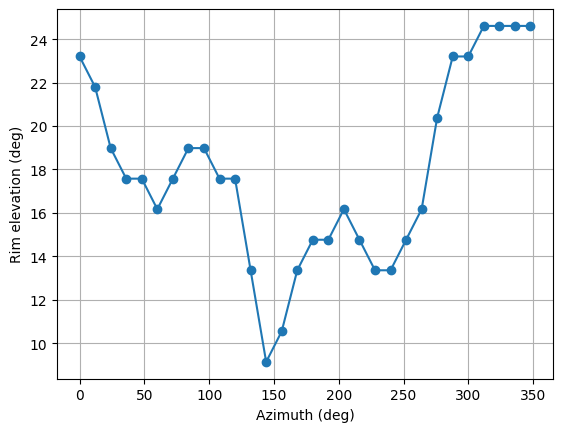

In [63]:
plt.figure()
plt.plot(az_mask, elev_mask, '-o')
plt.xlabel('Azimuth (deg)')
plt.ylabel('Rim elevation (deg)')
plt.grid(True)
plt.show()

In [64]:
print("az_mask:", az_mask[:10])
print("elev_mask:", elev_mask[:10])
print("elev min/max:", elev_mask.min(), elev_mask.max())


az_mask: [  0.  12.  24.  36.  48.  60.  72.  84.  96. 108.]
elev_mask: [23.203125 21.796875 18.984375 17.578125 17.578125 16.171875 17.578125
 18.984375 18.984375 17.578125]
elev min/max: 9.140625 24.609375


# 5. Combine GNSS and Lunar Sat

In [65]:
# Combine GNSS + lunar satellites at Shackleton

loc = "Shackleton"

# Load GNSS az/el for Shackleton (reuse Pablo's helper)
az_gnss, el_gnss = load_sat_data(sat_files[loc])

# Load the same horizon mask (already used in Part 4)
az_mask, elev_mask = load_mask(mask_files[loc])

# Apply mask to GNSS satellites (terrain-blocked GNSS geometry)
az_gnss_vis, el_gnss_vis = compute_masked_geometry(
    az_gnss, el_gnss, az_mask, elev_mask
)

print(f"{loc} – GNSS-only visible sats after mask: {len(az_gnss_vis)}")

# Build combined geometries for GNSS + LLO and GNSS + MLO
az_all_LLO = np.concatenate([az_gnss_vis, az_lunar_LLO_vis])
el_all_LLO = np.concatenate([el_gnss_vis, el_lunar_LLO_vis])

az_all_MLO = np.concatenate([az_gnss_vis, az_lunar_MLO_vis])
el_all_MLO = np.concatenate([el_gnss_vis, el_lunar_MLO_vis])

print(f"{loc} – GNSS+LLO total orbit points (visible): {len(az_all_LLO)}")
print(f"{loc} – GNSS+MLO total orbit points (visible): {len(az_all_MLO)}")

Shackleton – GNSS-only visible sats after mask: 0
Shackleton – GNSS+LLO total orbit points (visible): 8
Shackleton – GNSS+MLO total orbit points (visible): 26


In [66]:
az_mask, elev_mask = load_henry_mask(mask_file)

print("az_mask shape:", az_mask.shape)
print("elev_mask shape:", elev_mask.shape)
print("elev min/max:", elev_mask.min(), elev_mask.max())
print("first 10 elev:", elev_mask[:10])

az_mask shape: (30,)
elev_mask shape: (30,)
elev min/max: 9.140625 24.609375
first 10 elev: [23.203125 21.796875 18.984375 17.578125 17.578125 16.171875 17.578125
 18.984375 18.984375 17.578125]


# ADD High Circular Polar Orbit (HPO)

In [67]:
# High Lunar Orbit (HLO) – "NRHO-like" altitude
#    (Still 2-body circular polar, but high altitude)

altitude_HLO = 15000 * u.km     # 15,000 km above lunar surface
inclination_HLO = 90 * u.deg
epoch_HLO = Time("2025-01-01 00:00:00", scale="tdb")

lunar_orbit_HLO = Orbit.circular(
    Moon,
    alt=altitude_HLO,
    inc=inclination_HLO,
    epoch=epoch_HLO,
)

print("HLO orbit object:")
print(lunar_orbit_HLO)

# Sample one full HLO period with 200 points (same as LLO/MLO)
N_samples_HLO = 200
period_HLO = lunar_orbit_HLO.period
times_HLO = epoch_HLO + np.linspace(0, period_HLO.to(u.s).value, N_samples_HLO) * u.s

# Propagate and collect Moon-centered positions in meters
r_list_HLO = []
for t in times_HLO:
    rv_HLO = lunar_orbit_HLO.propagate(t - epoch_HLO)
    r_vec_HLO = rv_HLO.r.to(u.m).value   # (3,) numpy vector
    r_list_HLO.append(r_vec_HLO)

r_moon_HLO = np.array(r_list_HLO)   # shape: (N_samples_HLO, 3)

print(f"\nHLO orbital period ~ {period_HLO.to(u.hour):.2f}")
print(f"Number of samples: {N_samples_HLO}")

# Convert Moon-centered positions to az/el at Shackleton
#    Simple Moon-fixed geometry (no rotation over one orbit)

# Shackleton approximate location (geodetic)
lat_site_deg = -89.9   # near south pole
lon_site_deg = 0.0     # arbitrary (mask is symmetric in az anyway)

lat_site = np.deg2rad(lat_site_deg)
lon_site = np.deg2rad(lon_site_deg)

# Moon radius from poliastro
R_moon = Moon.R.to(u.m).value

# Site position in Moon-fixed frame
# (Treat inertial and body-fixed as aligned over one orbit)
r_site = R_moon * np.array([
    np.cos(lat_site) * np.cos(lon_site),
    np.cos(lat_site) * np.sin(lon_site),
    np.sin(lat_site),
])

# Local ENU basis vectors at the site
# Up (u), North (n), East (e)
u_vec = np.array([
    np.cos(lat_site) * np.cos(lon_site),
    np.cos(lat_site) * np.sin(lon_site),
    np.sin(lat_site),
])
n_vec = np.array([
    -np.sin(lat_site) * np.cos(lon_site),
    -np.sin(lat_site) * np.sin(lon_site),
    np.cos(lat_site),
])
e_vec = np.array([
    -np.sin(lon_site),
    np.cos(lon_site),
    0.0,
])

def positions_to_az_el(r_sat_array, r_site, e_vec, n_vec, u_vec):
    """
    Convert Moon-centered satellite positions to azimuth/elevation
    as seen from a fixed site on the lunar surface.
    """
    az_list = []
    el_list = []

    for r_sat in r_sat_array:
        r_rel = r_sat - r_site  # vector from site to satellite
        # Project into ENU frame
        e_comp = np.dot(r_rel, e_vec)
        n_comp = np.dot(r_rel, n_vec)
        u_comp = np.dot(r_rel, u_vec)

        # Range
        rho = np.linalg.norm(r_rel)

        # Elevation
        el = np.arcsin(u_comp / rho)  # radians

        # Azimuth (measured from North, positive towards East)
        az = np.arctan2(e_comp, n_comp)  # radians

        # Convert to degrees and wrap az to [0, 360)
        el_deg = np.rad2deg(el)
        az_deg = (np.rad2deg(az) + 360.0) % 360.0

        az_list.append(az_deg)
        el_list.append(el_deg)

    return np.array(az_list), np.array(el_list)

az_lunar_HLO, el_lunar_HLO = positions_to_az_el(
    r_moon_HLO, r_site, e_vec, n_vec, u_vec
)

# Apply Shackleton crater horizon mask
#    assumes az_mask, elev_mask already loaded

# Interpolate required elevation (rim) at each satellite azimuth
elev_required_HLO = np.interp(az_lunar_HLO % 360, az_mask, elev_mask)

# Visibility: satellite must be above crater rim
visible_HLO = el_lunar_HLO > elev_required_HLO

# Visibility stats coverage + minutes per orbit

def visibility_stats(visible, dt):
    """
    visible: boolean array over time
    dt:      timestep in seconds

    returns:
        coverage (0–1)
        durations_sec (array of visibility window durations in seconds)
    """
    visible = np.asarray(visible, dtype=bool)
    coverage = visible.mean()

    edges = np.diff(visible.astype(int))
    starts = np.where(edges == 1)[0] + 1
    ends   = np.where(edges == -1)[0] + 1

    if visible[0]:
        starts = np.r_[0, starts]
    if visible[-1]:
        ends = np.r_[ends, len(visible)]

    lengths = ends - starts  # in samples
    durations_sec = lengths * dt

    return coverage, durations_sec

# Time step and period for HLO
dt_HLO = period_HLO.to(u.s).value / (N_samples_HLO - 1)
T_orbit_HLO = period_HLO.to(u.s).value

cov_HLO, dur_HLO_sec = visibility_stats(visible_HLO, dt_HLO)

print("\n=== HLO Visibility (Shackleton) ===")
print(f"Orbital period: {T_orbit_HLO/60:.2f} minutes")
print(f"Visibility coverage: {cov_HLO*100:.2f}%")
print(f"Visibility durations (minutes): {dur_HLO_sec/60}")


N_vis = np.sum(visible_HLO)
print(f"Visible samples: {N_vis} / {N_samples_HLO}")


HLO orbit object:
16737 x 16737 km x 90.0 deg orbit around Moon (☾)

HLO orbital period ~ 53.97 h
Number of samples: 200

=== HLO Visibility (Shackleton) ===
Orbital period: 3238.46 minutes
Visibility coverage: 36.50%
Visibility durations (minutes): [1187.97777082]
Visible samples: 73 / 200


# Close Crater  Horizon Mask

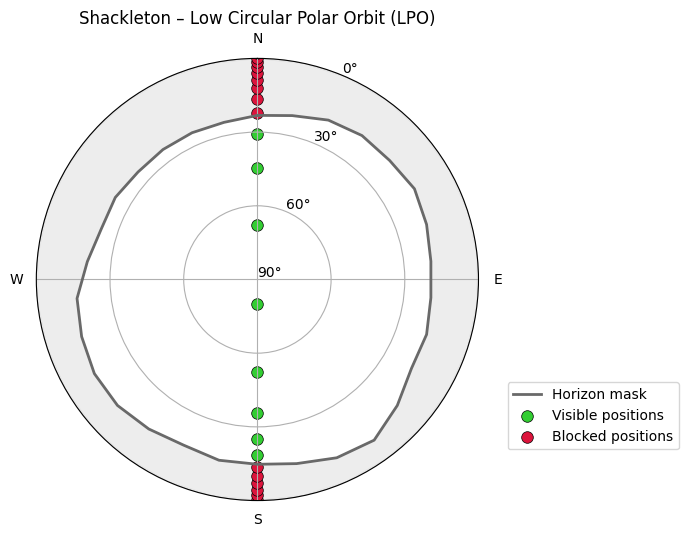

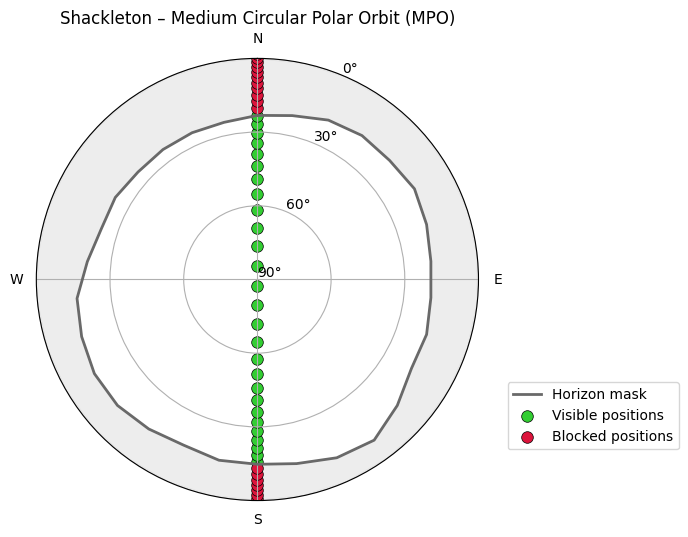

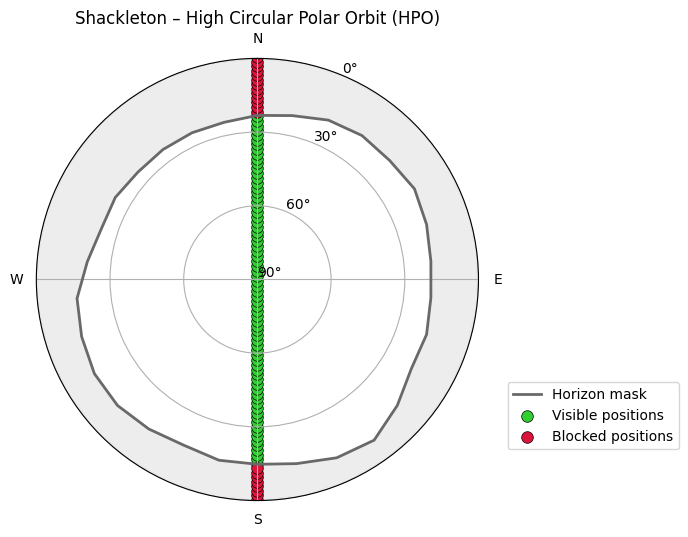

In [68]:
# Close the crater horizon mask (add 360° = 0° point)
az_mask_closed = az_mask.copy()
elev_mask_closed = elev_mask.copy()

# If last azimuth is < 360, append a copy of the first point at 360°
if az_mask_closed[-1] < 360.0:
    az_mask_closed = np.append(az_mask_closed, 360.0)
    elev_mask_closed = np.append(elev_mask_closed, elev_mask_closed[0])

def skyplot_lunar_sat(az_arr, el_arr, az_mask, elev_mask, title):
    """
    Simple skyplot for one lunar orbit (LLO, MLO, or HLO).
    az_arr, el_arr = satellite az/el (deg)
    az_mask, elev_mask = crater horizon mask (closed loop)
    """

    # Classify visibility
    visible = el_arr > np.interp(az_arr % 360, az_mask, elev_mask)
    
    # Convert to polar coordinates for skyplot
    theta_sat = np.deg2rad(az_arr)
    r_sat = 90 - el_arr  # 0° elevation at rim, 90° at center
    
    theta_mask = np.deg2rad(az_mask)
    r_mask = 90 - elev_mask

    plt.figure(figsize=(7,7))
    ax = plt.subplot(111, polar=True)

    # Polar configuration
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_rlim(0, 90)
    ax.set_rticks([90, 60, 30, 0])
    ax.set_yticklabels(["0°", "30°", "60°", "90°"])
    ax.set_thetagrids([0, 90, 180, 270], labels=["N", "E", "S", "W"])

    # Plot crater horizon (blocked region)
    theta_poly = np.concatenate([theta_mask, theta_mask[::-1]])
    r_poly = np.concatenate([r_mask, np.full_like(r_mask, 90.0)])
    ax.fill(theta_poly, r_poly, color="lightgray", alpha=0.4)

    # Plot mask curve
    ax.plot(theta_mask, r_mask, color="dimgray", linewidth=2, label="Horizon mask")

    # Visible positions
    ax.scatter(theta_sat[visible], r_sat[visible],
               s=70, c="limegreen", edgecolors="k", linewidths=0.5,
               label="Visible positions")

    # Blocked positions
    ax.scatter(theta_sat[~visible], r_sat[~visible],
               s=70, c="crimson", edgecolors="k", linewidths=0.5,
               label="Blocked positions")

    ax.set_title(title, pad=25)
    ax.legend(loc="lower left", bbox_to_anchor=(1.05, 0.1))
    plt.tight_layout()
    plt.show()


# PLOT ALL THREE ORBITS: LLO, MLO, HLO

skyplot_lunar_sat(az_lunar_LLO, el_lunar_LLO, az_mask_closed, elev_mask_closed,
                  "Shackleton – Low Circular Polar Orbit (LPO)")

skyplot_lunar_sat(az_lunar_MLO, el_lunar_MLO, az_mask_closed, elev_mask_closed,
                  "Shackleton – Medium Circular Polar Orbit (MPO)")

skyplot_lunar_sat(az_lunar_HLO, el_lunar_HLO, az_mask_closed, elev_mask_closed,
                  "Shackleton – High Circular Polar Orbit (HPO)")


# Elevation vs. Time

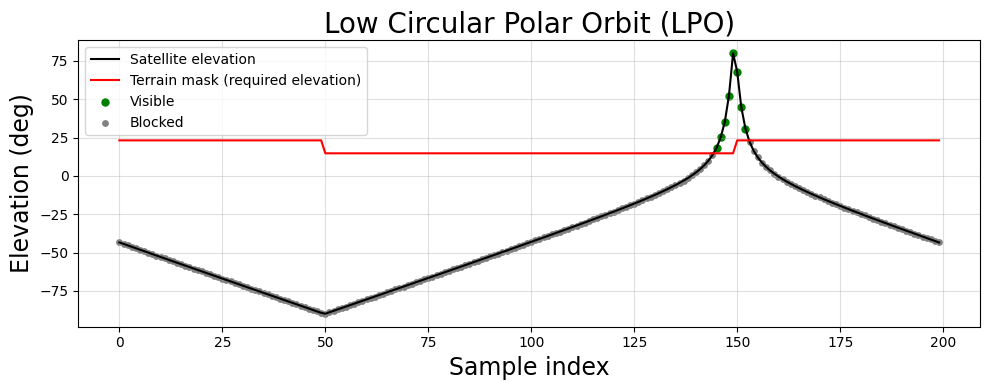

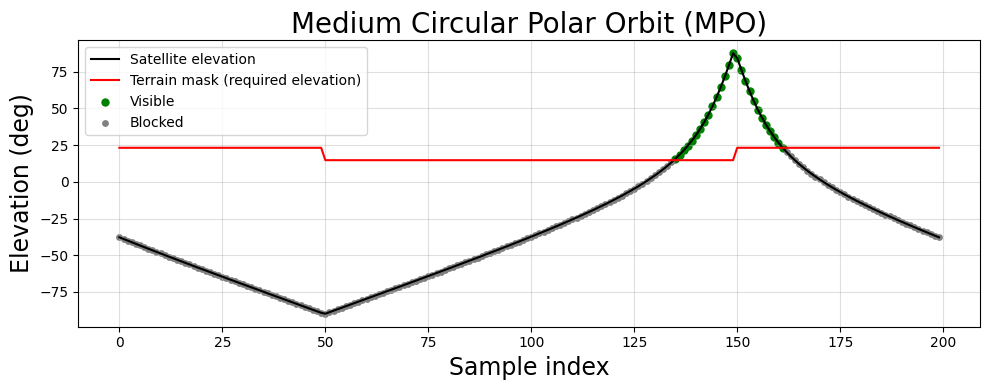

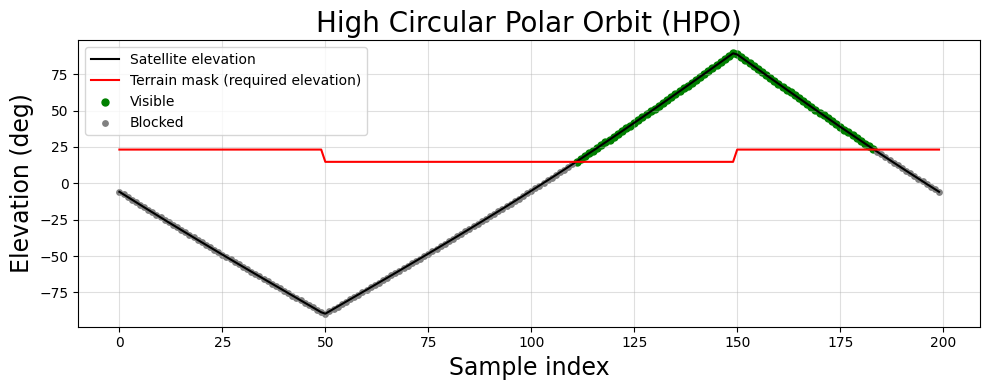

In [69]:
def plot_elevation_vs_time(el_arr, az_arr, az_mask, elev_mask, title):
    """
    Plot satellite elevation vs sample index, with the crater rim
    (required elevation from the horizon mask) overlaid.
    """

    el_arr = np.asarray(el_arr)
    az_arr = np.asarray(az_arr)

    # Required elevation from crater rim at each sample's azimuth
    elev_required = np.interp(az_arr % 360.0, az_mask, elev_mask)

    # Visibility: satellite must be above the rim
    visible = el_arr > elev_required

    # Plot
    plt.figure(figsize=(10, 4))
    plt.plot(el_arr, label="Satellite elevation", color="black")
    plt.plot(elev_required, label="Terrain mask (required elevation)", color="red")

    # Mark visible and blocked samples
    idx = np.arange(len(el_arr))
    plt.scatter(idx[visible], el_arr[visible],
                color="green", s=25, label="Visible")
    plt.scatter(idx[~visible], el_arr[~visible],
                color="gray", s=15, label="Blocked")

    plt.title(title, fontsize=20)
    plt.xlabel("Sample index", fontsize=17)
    plt.ylabel("Elevation (deg)", fontsize=17)
    plt.legend()
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

# Use the CLOSED mask to be consistent with the skyplots
plot_elevation_vs_time(el_lunar_LLO, az_lunar_LLO,
                       az_mask_closed, elev_mask_closed,
                       "Low Circular Polar Orbit (LPO)")

plot_elevation_vs_time(el_lunar_MLO, az_lunar_MLO,
                       az_mask_closed, elev_mask_closed,
                       "Medium Circular Polar Orbit (MPO)")

# NEW: HLO elevation vs time
plot_elevation_vs_time(el_lunar_HLO, az_lunar_HLO,
                       az_mask_closed, elev_mask_closed,
                       "High Circular Polar Orbit (HPO)")

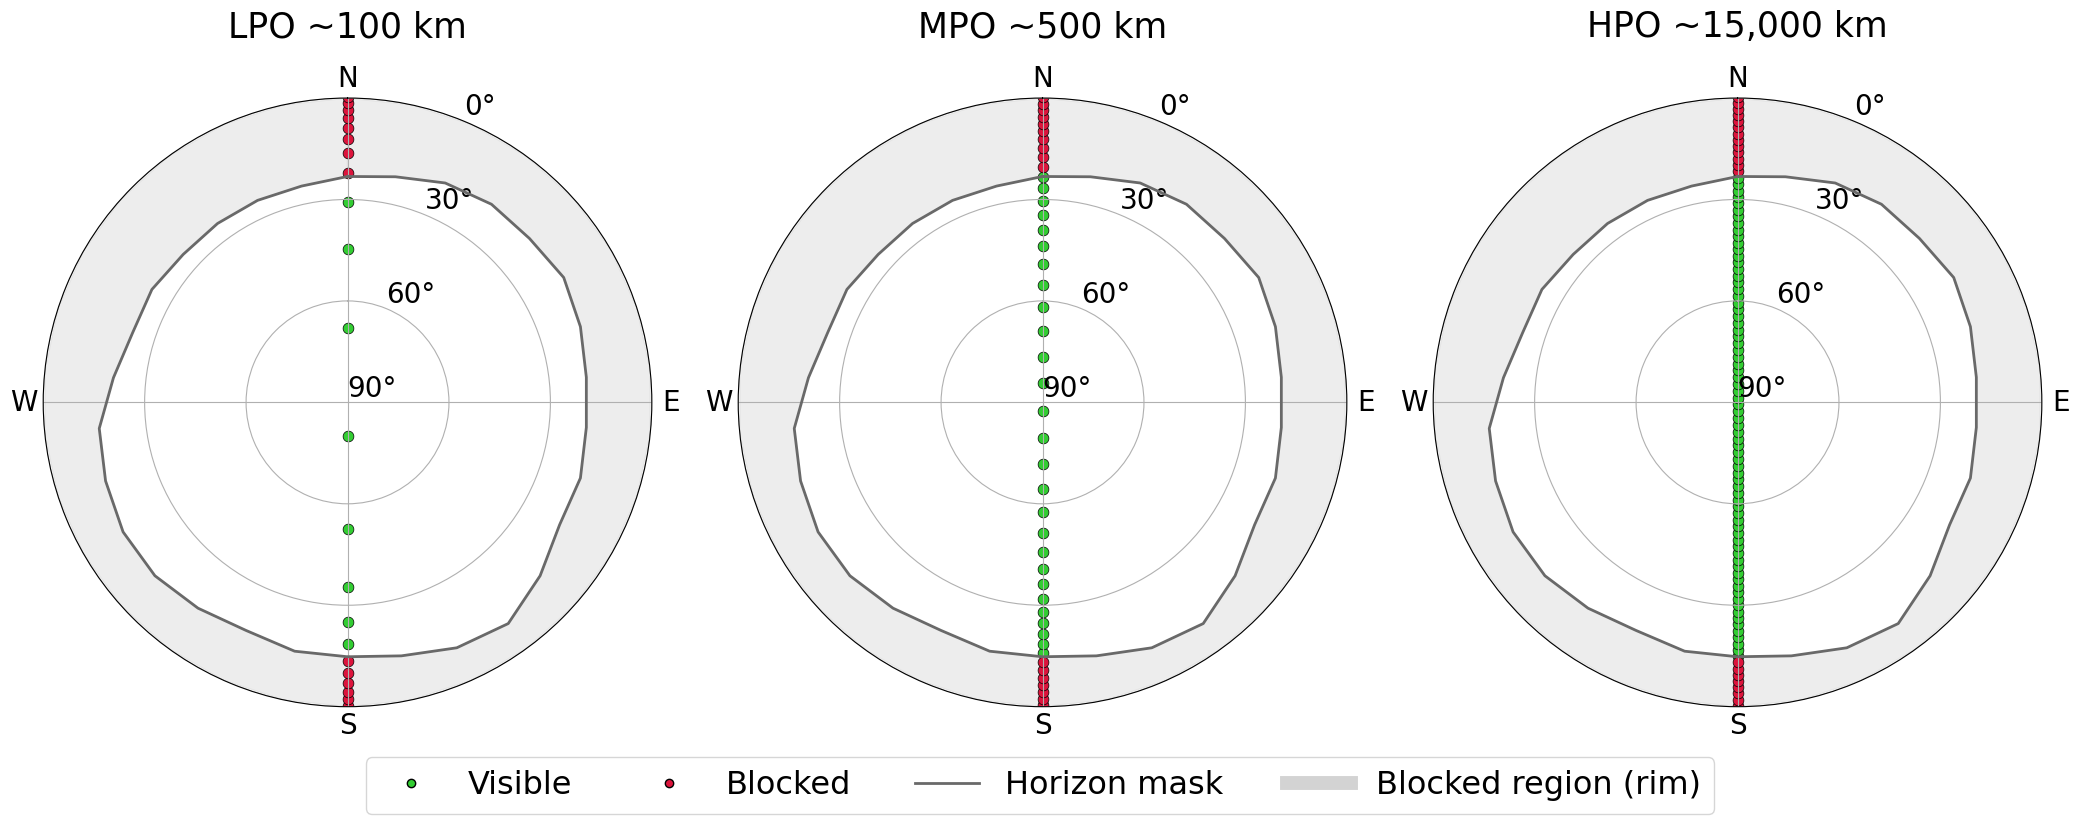

In [70]:
# HELPER: Plot skyplot onto a given axis
def skyplot_on_axis(ax, az_arr, el_arr, az_mask, elev_mask, title):
    """Plot one skyplot on a given axis object."""
    
    # Compute visibility
    visible = el_arr > np.interp(az_arr % 360, az_mask, elev_mask)

    # Convert to polar coords
    theta_sat = np.deg2rad(az_arr)
    r_sat = 90 - el_arr

    theta_mask = np.deg2rad(az_mask)
    r_mask = 90 - elev_mask

    # Polar setup
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_rlim(0, 90)
    ax.set_rticks([90, 60, 30, 0])
    ax.set_yticklabels(["0°", "30°", "60°", "90°"], fontsize=20)
    ax.set_thetagrids(
    [0, 90, 180, 270],
    labels=["N", "E", "S", "W"],
    fontsize=20   
    )


    # Blocked region
    theta_poly = np.concatenate([theta_mask, theta_mask[::-1]])
    r_poly = np.concatenate([r_mask, np.full_like(r_mask, 90.0)])
    ax.fill(theta_poly, r_poly, color="lightgray", alpha=0.4)

    # Rim curve
    ax.plot(theta_mask, r_mask, color="dimgray", linewidth=2)

    # Visible samples
    ax.scatter(theta_sat[visible], r_sat[visible],
               s=60, c="limegreen", edgecolors="k", linewidths=0.5)

    # Blocked samples
    ax.scatter(theta_sat[~visible], r_sat[~visible],
               s=60, c="crimson", edgecolors="k", linewidths=0.5)

    ax.set_title(title, pad=20, fontsize=25)


# PLOT ALL 3 SKYplots SIDE BY SIDE
fig, axes = plt.subplots(1, 3, figsize=(21, 7), subplot_kw={'polar': True})

skyplot_on_axis(axes[0], az_lunar_LLO, el_lunar_LLO, az_mask_closed, elev_mask_closed,
                "LPO ~100 km")

skyplot_on_axis(axes[1], az_lunar_MLO, el_lunar_MLO, az_mask_closed, elev_mask_closed,
                "MPO ~500 km")

skyplot_on_axis(axes[2], az_lunar_HLO, el_lunar_HLO, az_mask_closed, elev_mask_closed,
                "HPO ~15,000 km")

# ONE SHARED LEGEND
dummy_visible = plt.Line2D([0],[0], marker='o', color='limegreen', label='Visible', 
                           markerfacecolor='limegreen', markeredgecolor='k', linewidth=0)
dummy_blocked = plt.Line2D([0],[0], marker='o', color='crimson', label='Blocked', 
                           markerfacecolor='crimson', markeredgecolor='k', linewidth=0)
dummy_mask = plt.Line2D([0],[0], color='dimgray', linewidth=2, label='Horizon mask')
dummy_fill = plt.Line2D([0],[0], color='lightgray', linewidth=10, label='Blocked region (rim)')

fig.legend(handles=[dummy_visible, dummy_blocked, dummy_mask, dummy_fill],
           loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=4, fontsize=23)

plt.tight_layout()
plt.show()